# Exploratory Data Analysis (EDA) - APP La Campiña

Este notebook realiza un análisis exploratorio de los datos de prueba del sistema para entender la distribución de pedidos, clientes, productos y vendedores.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Definir la ruta de los datos (relativa desde la carpeta APP_Lacampiña2.0)
data_path = '../datos de prueba/'


## 1. Carga de Datos


In [3]:
def load_excel(filename):
    path = os.path.join(data_path, filename)
    return pd.read_excel(path)

df_clientes = load_excel('CLIENTES.xlsx')
df_pedidos = load_excel('PurchaseOrderDetailsReport (12).xlsx')
df_productos = load_excel('TOMAPEDIDOS_PRODUCTOS (10).xlsx')
df_ubicaciones = load_excel('UBICACIONES.xlsx')
df_vendedores = load_excel('VENDEDORES.xlsx')

print(f'Clientes: {df_clientes.shape}')
print(f'Pedidos (Detalles): {df_pedidos.shape}')
print(f'Productos: {df_productos.shape}')
print(f'Ubicaciones: {df_ubicaciones.shape}')
print(f'Vendedores: {df_vendedores.shape}')


Clientes: (848, 30)
Pedidos (Detalles): (22235, 36)
Productos: (540, 30)
Ubicaciones: (324, 4)
Vendedores: (4, 15)


## 2. Limpieza y Unión de Datos (Ubicaciones y Clientes)
Como se identificó previamente, las coordenadas en la tabla de clientes suelen estar en cero, y las correctas están en UBICACIONES.xlsx.

In [4]:
# Extraer latitud y longitud de UBICACIONES
def split_coordinates(coord):
    if pd.isna(coord): return pd.Series([None, None])
    parts = str(coord).split(',')
    if len(parts) == 2:
        return pd.Series([float(parts[0].strip()), float(parts[1].strip())])
    return pd.Series([None, None])

df_ubicaciones[['LATITUD_CORRECTA', 'LONGITUD_CORRECTA']] = df_ubicaciones['COORDENADAS'].apply(split_coordinates)

# Join clientes con ubicaciones por nombre de negocio o nombre para actualizar coordenadas
# Normalizamos texto para el cruce
df_clientes['join_key'] = df_clientes['NOMBRE DEL NEGOCIO (Obligatorio)'].astype(str).str.strip().str.upper()
df_ubicaciones['join_key'] = df_ubicaciones['NOMBRE'].astype(str).str.strip().str.upper()

df_clientes_geo = pd.merge(df_clientes, df_ubicaciones[['join_key', 'LATITUD_CORRECTA', 'LONGITUD_CORRECTA']], on='join_key', how='left')

print(f'Clientes con coordenadas recuperadas: {df_clientes_geo["LATITUD_CORRECTA"].notna().sum()}')


Clientes con coordenadas recuperadas: 200


## 3. Análisis de Pedidos


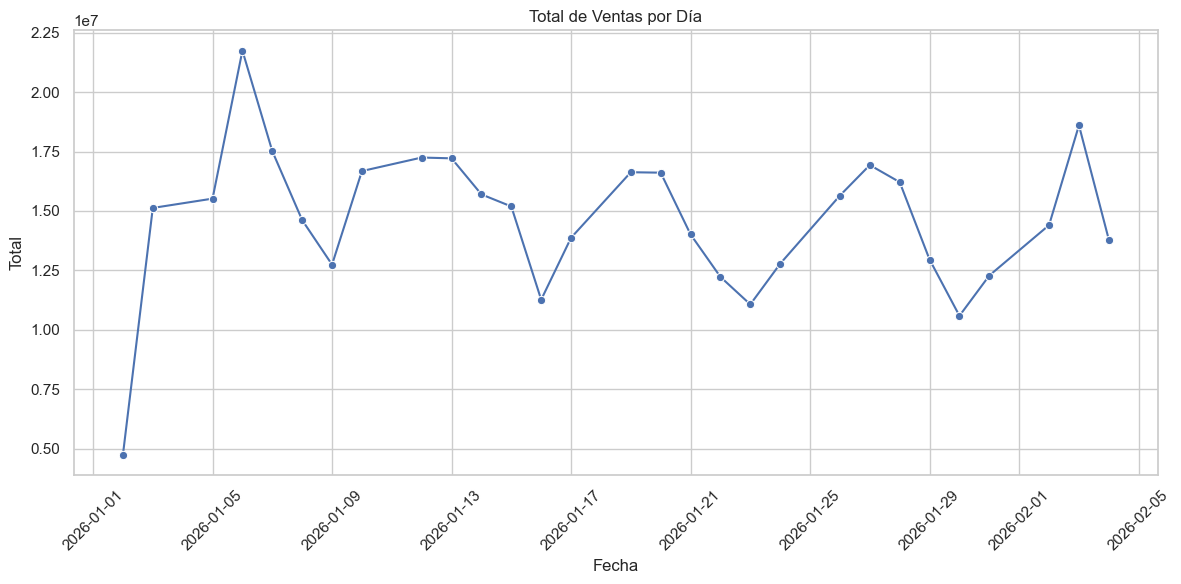

In [5]:
# Convertir fecha a datetime
df_pedidos['Fecha'] = pd.to_datetime(df_pedidos['Fecha'])

# Ventas por día
ventas_por_dia = df_pedidos.groupby('Fecha')['Total'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=ventas_por_dia, x='Fecha', y='Total', marker='o')
plt.title('Total de Ventas por Día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


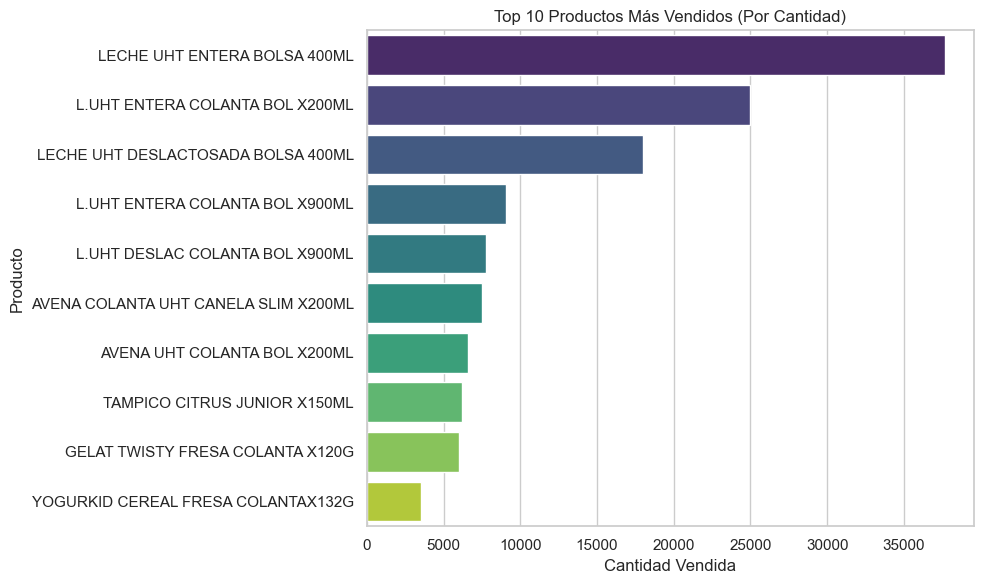

In [6]:
# Top 10 Productos más vendidos según cantidad
top_productos = df_pedidos.groupby('Producto')['Cantidad'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=top_productos.index, x=top_productos.values, palette='viridis')
plt.title('Top 10 Productos Más Vendidos (Por Cantidad)')
plt.xlabel('Cantidad Vendida')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()


## 4. Análisis de Clientes y Geografía


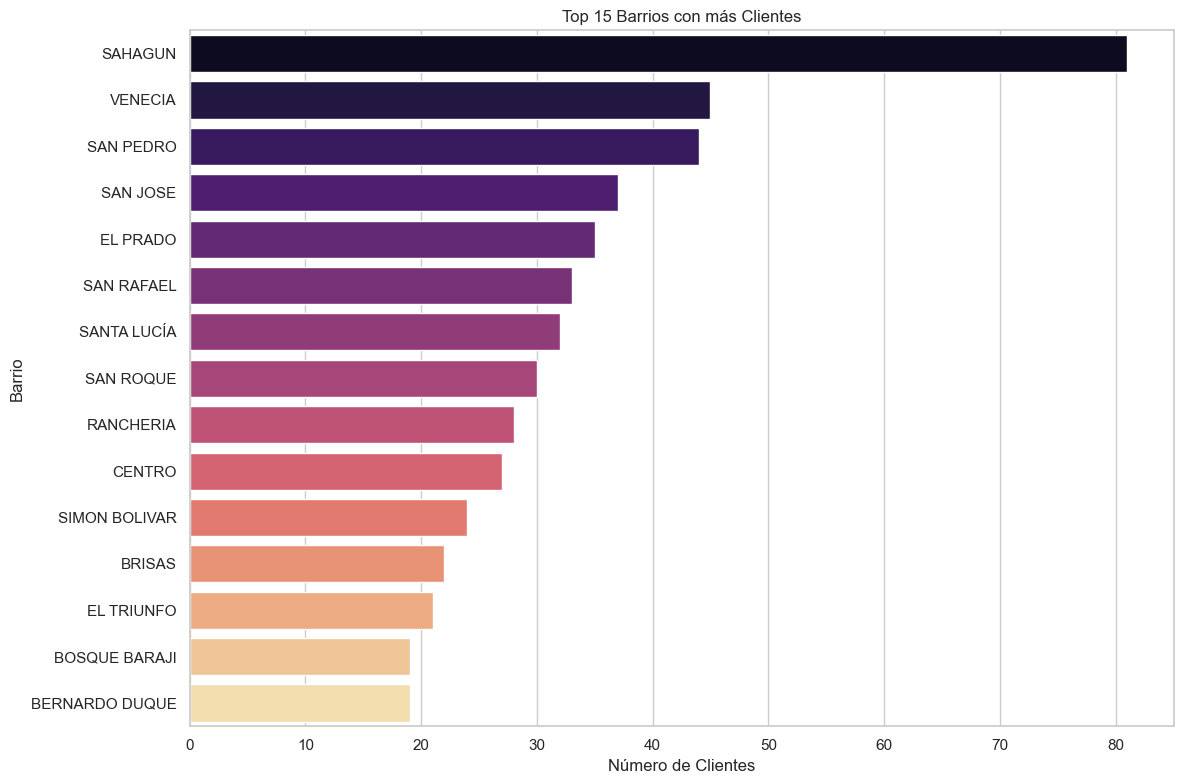

In [7]:
# Distribución de clientes por barrio (Top 15)
top_barrios = df_clientes['BARRIO'].value_counts().head(15)
plt.figure(figsize=(12,8))
sns.barplot(y=top_barrios.index, x=top_barrios.values, palette='magma')
plt.title('Top 15 Barrios con más Clientes')
plt.xlabel('Número de Clientes')
plt.ylabel('Barrio')
plt.tight_layout()
plt.show()


## 5. Visualización Espacial Básica (Scatter plot de Coordenadas)


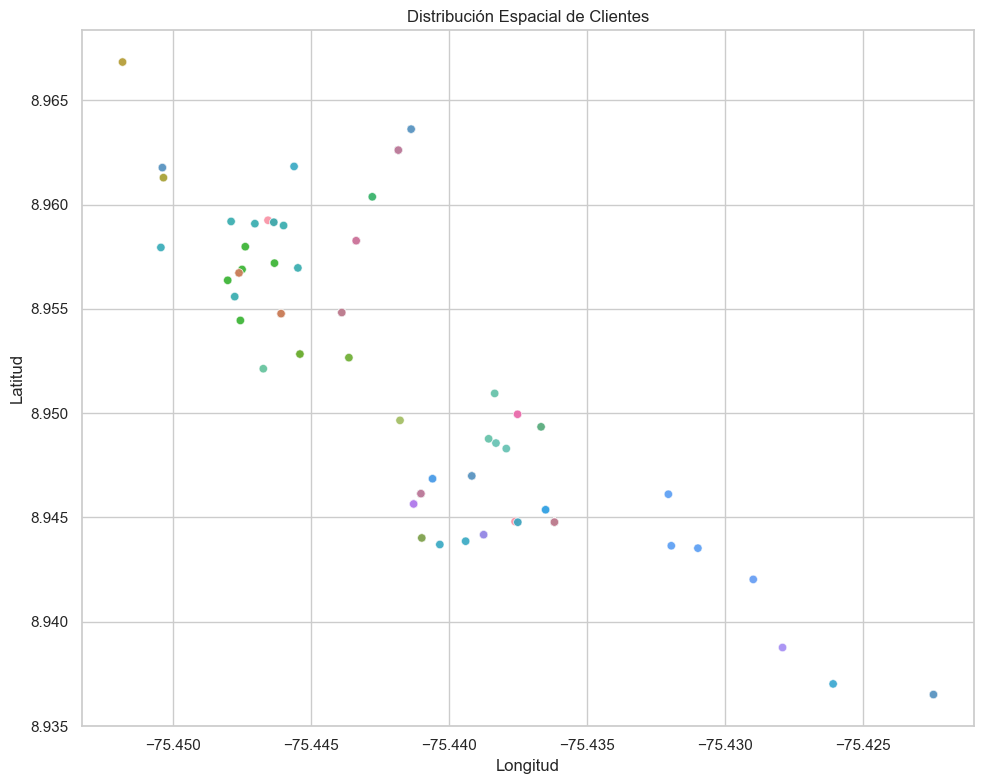

In [8]:
# Graficar ubicaciones de clientes recuperadas de UBICACIONES.xlsx
df_plot = df_clientes_geo.dropna(subset=['LATITUD_CORRECTA', 'LONGITUD_CORRECTA'])
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_plot, x='LONGITUD_CORRECTA', y='LATITUD_CORRECTA', hue='BARRIO', legend=False, alpha=0.7)
plt.title('Distribución Espacial de Clientes')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.tight_layout()
plt.show()
